In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
import mlflow
import mlflow.sklearn
import mlflow.xgboost

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic equipment data
n_samples = 10000

# Features
temperature = np.random.normal(75, 15, n_samples)  # °C
vibration = np.random.normal(0.5, 0.2, n_samples)  # mm/s
pressure = np.random.normal(100, 20, n_samples)    # PSI
rpm = np.random.normal(1500, 200, n_samples)       # RPM
age_days = np.random.randint(0, 365, n_samples)    # Days since maintenance

# Create failure condition (combination of factors)
failure_score = (
    (temperature > 90) * 0.3 +
    (vibration > 0.8) * 0.3 +
    (pressure > 130) * 0.2 +
    (age_days > 300) * 0.2
)

# Add some randomness and set threshold
failure_prob = failure_score + np.random.normal(0, 0.1, n_samples)
failure = (failure_prob > 0.5).astype(int)

# Create DataFrame
data = pd.DataFrame({
    'temperature': temperature,
    'vibration': vibration,
    'pressure': pressure,
    'rpm': rpm,
    'age_days': age_days,
    'failure': failure
})

print(f'Dataset shape: {data.shape}')
print(f'Failure rate: {data.failure.mean():.2%}')
data.head()

Dataset shape: (10000, 6)
Failure rate: 4.15%


,temperature,vibration,pressure,rpm,age_days,failure
0,82.450712,0.364301,106.965725,1103.885606,187,0
1,72.926035,0.438900,105.666472,1289.002871,239,0
2,84.715328,0.380524,81.269603,1382.594319,2,0
3,97.845448,0.522084,111.591684,1529.933782,5,0
4,71.487699,0.739436,70.198346,1704.832465,259,0


--- Summary Statistics ---
        temperature     vibration      pressure           rpm      age_days  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean      74.967960      0.502707     99.750745   1498.485705    181.908000   
std       15.051936      0.200202     19.828363    200.897414    105.568632   
min       16.163996     -0.271275     26.898270    606.879227      0.000000   
25%       64.911142      0.367598     85.996962   1361.077430     90.000000   
50%       74.961075      0.503169     99.884635   1497.923551    182.000000   
75%       85.066213      0.638773    113.277949   1635.806091    272.000000   
max      133.893566      1.395817    173.832490   2245.566669    364.000000   

            failure  
count  10000.000000  
mean       0.041500  
std        0.199454  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%        0.000000  
max        1.000000  

--- Missing Values ---
temperature    0
vibration      0
press

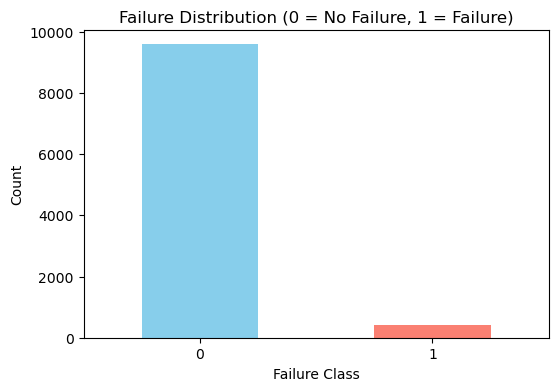

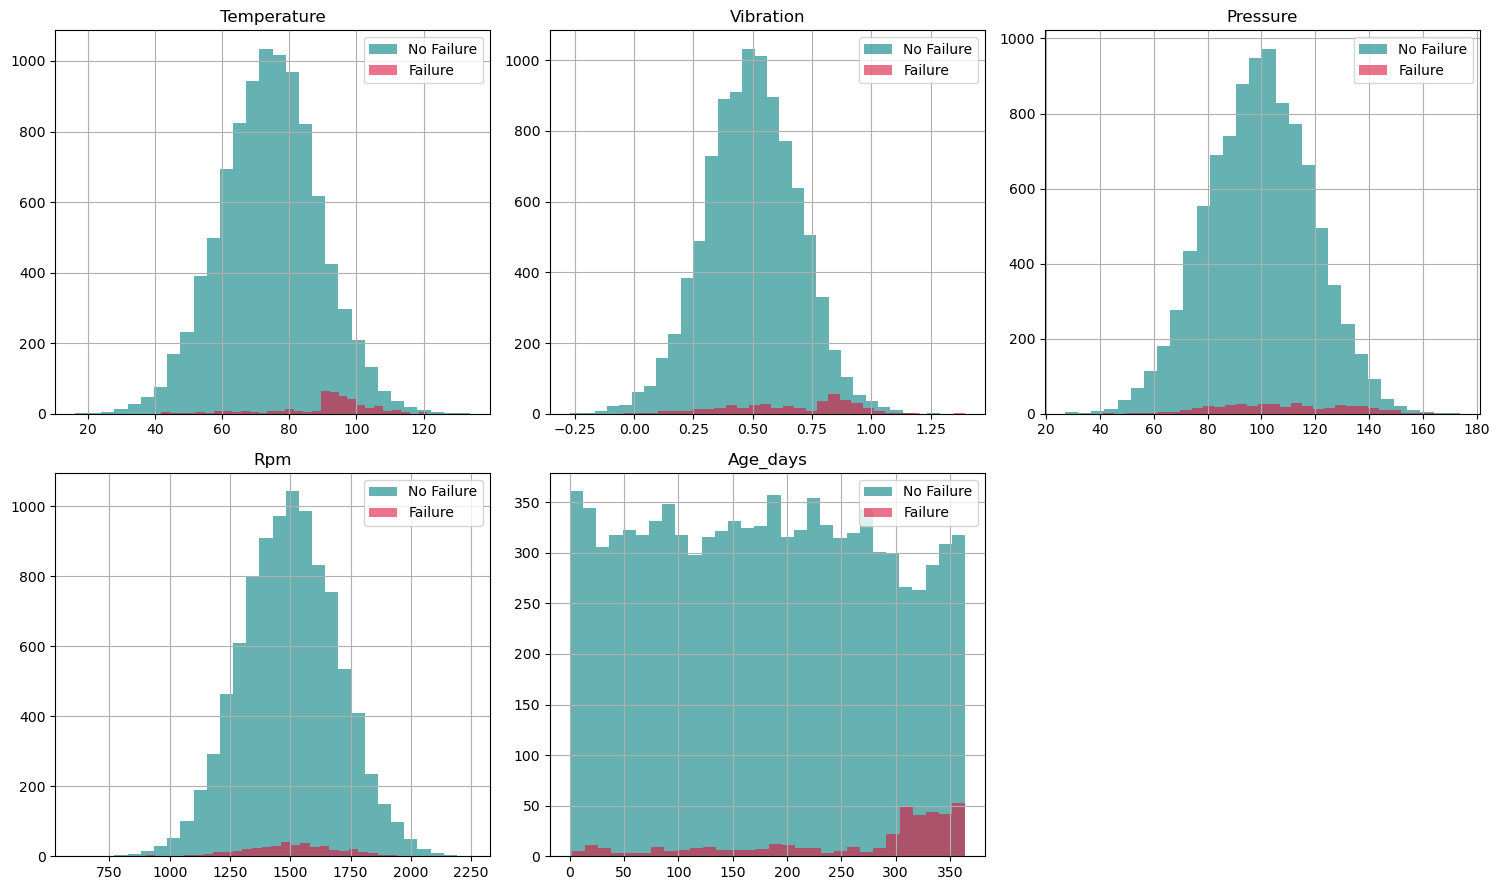

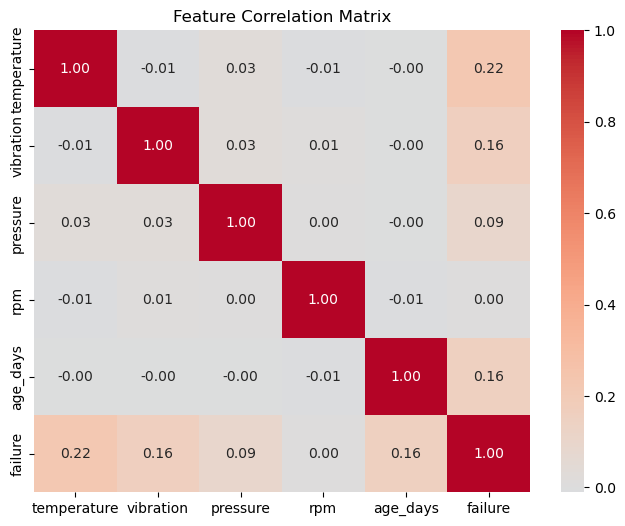

In [2]:
# Summary statistics & data integrity check
print('--- Summary Statistics ---')
print(data.describe())

print('\n--- Missing Values ---')
print(data.isnull().sum())

# Class distribution plot
plt.figure(figsize=(6, 4))
data.failure.value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Failure Distribution (0 = No Failure, 1 = Failure)')
plt.xlabel('Failure Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# Feature distributions split by target class
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
features = ['temperature', 'vibration', 'pressure', 'rpm', 'age_days']

for idx, feature in enumerate(features):
    ax = axes[idx // 3, idx % 3]
    data[data.failure == 0][feature].hist(ax=ax, alpha=0.6, label='No Failure', bins=30, color='teal')
    data[data.failure == 1][feature].hist(ax=ax, alpha=0.6, label='Failure', bins=30, color='crimson')
    ax.set_title(feature.capitalize())
    ax.legend()

# Remove the empty 6th subplot
fig.delaxes(axes[1, 2])
plt.tight_layout()
plt.show()

# Heatmap correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

In [3]:
# Configure MLflow Connection
mlflow.set_tracking_uri('http://localhost:5000')
mlflow.set_experiment('predictive-maintenance')

print(f'MLflow Tracking URI: {mlflow.get_tracking_uri()}')
print(f'Active Experiment: {mlflow.get_experiment_by_name("predictive-maintenance").name}')
print("-" * 50)

# Split features and target
X = data.drop('failure', axis=1)
y = data['failure']

# Stratified Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training Set Shapes: X={X_train.shape}, y={y_train.shape}')
print(f'Testing Set Shapes:  X={X_test.shape}, y={y_test.shape}')
print(f'Train Failure Rate:  {y_train.mean():.2%}')
print(f'Test Failure Rate:   {y_test.mean():.2%}')

2026/06/07 10:05:39 INFO mlflow.tracking.fluent: Experiment with name 'predictive-maintenance' does not exist. Creating a new experiment.


MLflow Tracking URI: http://localhost:5000
Active Experiment: predictive-maintenance
--------------------------------------------------
Training Set Shapes: X=(8000, 5), y=(8000,)
Testing Set Shapes:  X=(2000, 5), y=(2000,)
Train Failure Rate:  4.15%
Test Failure Rate:   4.15%


In [4]:
with mlflow.start_run(run_name='logistic_regression'):
    # Parameters
    C = 1.0
    max_iter = 1000
    
    mlflow.log_param('C', C)
    mlflow.log_param('max_iter', max_iter)
    mlflow.log_param('model_type', 'LogisticRegression')
    
    # Train
    lr_model = LogisticRegression(C=C, max_iter=max_iter, random_state=42)
    lr_model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = lr_model.predict(X_test_scaled)
    y_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
    
    # Metrics
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred_proba)
    }
    
    # Log metrics & artifact model
    mlflow.log_metrics(metrics)
    mlflow.sklearn.log_model(lr_model, 'model')
    
    print('Logistic Regression Results:')
    for metric_name, val in metrics.items():
        print(f'- {metric_name.replace("_", " ").capitalize()}: {val:.4f}')

2026/06/07 10:05:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/07 10:05:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logistic Regression Results:
- Accuracy: 0.9620
- Precision: 0.6842
- Recall: 0.1566
- F1 score: 0.2549
- Roc auc: 0.9234
🏃 View run logistic_regression at: http://localhost:5000/#/experiments/2/runs/3a0e409c6f34438da45b3304b61a7caa
🧪 View experiment at: http://localhost:5000/#/experiments/2


In [5]:
with mlflow.start_run(run_name='random_forest'):
    # Parameters
    n_estimators = 100
    max_depth = 10
    min_samples_split = 5
    
    mlflow.log_param('n_estimators', n_estimators)
    mlflow.log_param('max_depth', max_depth)
    mlflow.log_param('min_samples_split', min_samples_split)
    mlflow.log_param('model_type', 'RandomForest')
    
    # Train
    rf_model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42
    )
    rf_model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = rf_model.predict(X_test_scaled)
    y_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]
    
    # Metrics
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred_proba)
    }
    
    # Log metrics & artifact model
    mlflow.log_metrics(metrics)
    mlflow.sklearn.log_model(rf_model, 'model')
    
    print('Random Forest Results:')
    for metric_name, val in metrics.items():
        print(f'- {metric_name.replace("_", " ").capitalize()}: {val:.4f}')

2026/06/07 10:06:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/07 10:06:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest Results:
- Accuracy: 0.9670
- Precision: 0.6049
- Recall: 0.5904
- F1 score: 0.5976
- Roc auc: 0.9751
🏃 View run random_forest at: http://localhost:5000/#/experiments/2/runs/6f08cd37c3b4475fae0a0390c93aeef6
🧪 View experiment at: http://localhost:5000/#/experiments/2


In [6]:
with mlflow.start_run(run_name='xgboost'):
    # Parameters
    n_estimators = 100
    max_depth = 6
    learning_rate = 0.1
    
    mlflow.log_param('n_estimators', n_estimators)
    mlflow.log_param('max_depth', max_depth)
    mlflow.log_param('learning_rate', learning_rate)
    mlflow.log_param('model_type', 'XGBoost')
    
    # Train
    xgb_model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        random_state=42,
        eval_metric='logloss'
    )
    xgb_model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = xgb_model.predict(X_test_scaled)
    y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]
    
    # Metrics
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred_proba)
    }
    
    # Log metrics & native model tracking
    mlflow.log_metrics(metrics)
    mlflow.xgboost.log_model(xgb_model, 'model')
    
    print('XGBoost Results:')
    for metric_name, val in metrics.items():
        print(f'- {metric_name.replace("_", " ").capitalize()}: {val:.4f}')

2026/06/07 10:06:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


XGBoost Results:
- Accuracy: 0.9670
- Precision: 0.6076
- Recall: 0.5783
- F1 score: 0.5926
- Roc auc: 0.9709
🏃 View run xgboost at: http://localhost:5000/#/experiments/2/runs/ea7990b7c63942aabc484bc14924d1ee
🧪 View experiment at: http://localhost:5000/#/experiments/2
